House Price Prediction using Machine Learning

Name: Dharani Kankanala

Internship: XYlofy AI Internship Program

Project: Week 1 – House Price Prediction

Objective:
To build machine learning models that predict house prices based on various house features and identify the factors that influence house prices.

**Task 1 - Data Loading & Exploration**

In [67]:
## IMPORT LIBRARIES  ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [68]:
## LOAD DATASET ##
df=pd.read_csv("/Housing.csv.zip")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [69]:
## DISPLAY FIRST 10 ROWS ##
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [70]:
## CHECK DATASET SHAPE ##
print("shape of dataset:")
print(df.shape)

shape of dataset:
(545, 13)


In [71]:
## DISPLAY ALL COLUMNS ##
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [72]:
## IDENTIFY TARGET AND FEATURES ##
target = 'price'
features = df.columns.drop(target)
print("Target variable:")
print(target)
print("\nFeatures:")
print(features)

Target variable:
price

Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')


In [73]:
## CHECK MISSING VALUES ##
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [74]:
## CHECK DUPLICATE ROWS ##
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
0


Task 1: Conclusion

The dataset contains 545 rows and 13 columns. The target variable is house price, and the remaining columns are used as features to predict house prices. Missing values and duplicate rows were checked before moving to data cleaning

**Task 2 - Data Cleaning**

In this section, missing values are handled, duplicate rows are removed, categorical variables are converted into numerical format, and only meaningful features are retained for house price prediction.

In [75]:
## Step 1 : Check missing values ##
print("Missing values in each column:")
print(df.isnull().sum())
## Step 2 : Handle missing values
df = df.dropna()
print("Shape after handling missing values:")
print(df.shape)
## Step 3 : Remove duplicate rows ##
print("Duplicate rows before removal:")
print(df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after removal:")
print(df.duplicated().sum())

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Shape after handling missing values:
(545, 13)
Duplicate rows before removal:
0
Duplicate rows after removal:
0


In [76]:
## Step 4: Convert categorical columns into numeric values ##
categorical_columns = df.select_dtypes(include='object').columns
print(categorical_columns)
## Now convert them ##
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())
## Step 5: Check the new shape of dataset ##
print("New dataset shape:")
print(df_encoded.shape)
## Step 6: Verify all columns are numeric ##
print(df_encoded.dtypes)
## Step 7: Convert booleans columns to integers ##
bool_columns= df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)
print(df_encoded.dtypes)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True 

Task 2: Conclusion

The dataset was cleaned and prepared for machine learning. There were no missing values or duplicate rows. Categorical variables were converted into numerical values using one-hot encoding, and all features were transformed into a machine-readable format.

**Task 3 - Model Building**

In [77]:
## Step 1: Split Features and Target ##
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
print("Features shape:", X.shape)
print("Target shape:", y.shape)
## Step 2: Split Data ##
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Features shape: (545, 13)
Target shape: (545,)
Training data: (436, 13)
Testing data: (109, 13)


In [78]:
## Step 3: Train Linear Regression ##
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
print("Linear Regression model trained successfully!")
## Step 4: Evaluate Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)
print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression model trained successfully!
Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


In [79]:
## Step 5: Train Randrom Forest Regressor ##
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=4)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
print("Random Forest model trained successfully!")
## step 6: Evaluate Random Forest ##
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)
print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest model trained successfully!
Random Forest Results
MAE: 1011391.1842507644
RMSE: 1380417.9370678382
R2 Score: 0.6230038187022937


In [80]:
## Step 7: Compare Both Models ##
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Linear Regression': [lr_mae, lr_rmse, lr_r2],
    'Random Forest': [rf_mae, rf_rmse, rf_r2]
  })
comparison

,Metric,Linear Regression,Random Forest
0,MAE,9.700434e+05,1.011391e+06
1,RMSE,1.324507e+06,1.380418e+06
2,R2 Score,6.529243e-01,6.230038e-01


Task 3: Conclusion

Two regression models were trained to predict house prices. Linear Regression served as a baseline model, while Random Forest captured more complex relationships in the data. The models were evaluated using MAE, RMSE, and R² Score, and their performances were compared.

**Task 4 — Visualization (Minimum 3 charts)**

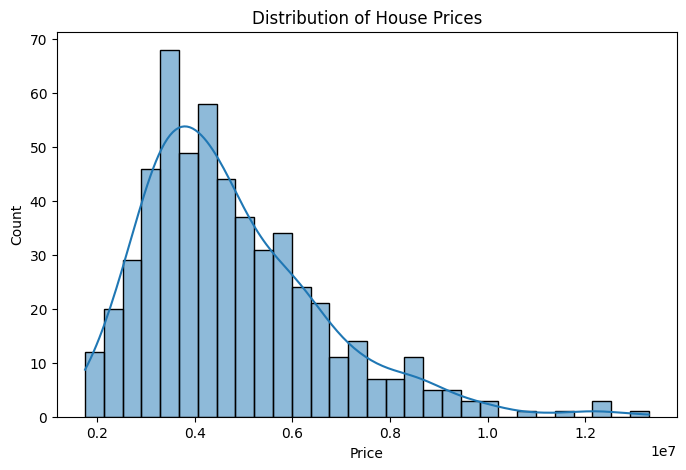

In [81]:
 ## Chart 1: Histogram showing the distribution of house prices ##
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.savefig('histogram.png')
plt.show()

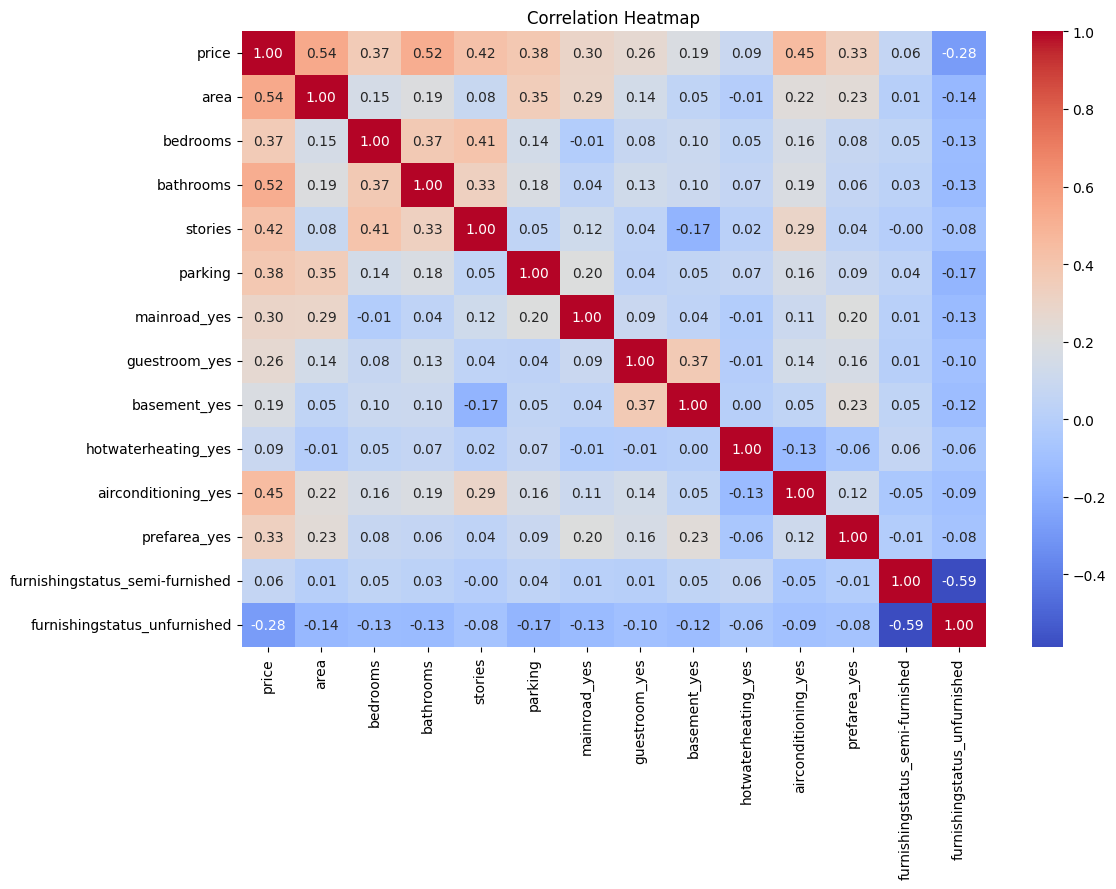

In [82]:
## Chart 2: Correlation Heatmap ##
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('heatmap.png')
plt.show()

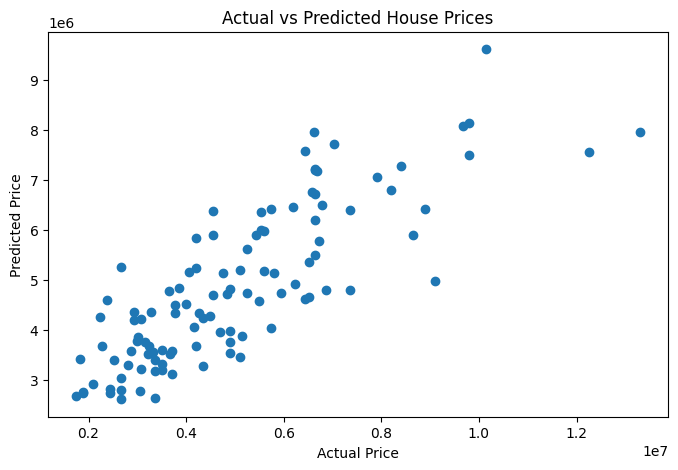

In [83]:
## Chart 3 - Actual vs Predicted Scatter Plot ##
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_predictions)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.savefig('actual_vs_predicted.png')
plt.show()

**Task 5 - Insights & Summary**

1)Which features influence house price the most?

The correlation heatmap showed that area, bathrooms, air conditioning, stories, and parking have a strong influence on house prices. Larger houses with more facilities generally have higher prices.

2)How accurate was your model?

The Linear Regression model achieved an R² score of approximately 0.65, which means it could explain around 65% of the variation in house prices. This indicates a reasonably good prediction performance.

3)What surprised you in the data?

It was interesting to observe that some non-numerical features such as air conditioning, preferred area, and furnishing status significantly affected house prices.

4)One recommendation for a real estate business.

Real estate companies should focus on properties with larger areas, more bathrooms, parking facilities, and modern amenities because these features strongly influence property value.